- Purpose: Outlier checks help detect data points that are unusual or suspicious.
- Excessive gaps in distribution: If the data jumps suddenly or has huge gaps compared to the normal pattern, it could indicate an error.
- Deviation from station-specific climatology: Each weather station has its own typical range (average temperatures, rainfall, etc.). Values far outside this range are likely mistakes.

In [64]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# from saqc import SaQC
import metpyqc as qc

from qc_func import *
from fake_data_design import *
from visualizaion_func import *

In [66]:
import sqlalchemy as sa
from sqlalchemy.orm import Session
import sys
function_path = '../'
sys.path.append(function_path)
from crmprtd import setup_logging

save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

In [67]:
### Check all the variables'name
sql_text = sa.text("""
SELECT DISTINCT v.net_var_name
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 11
AND h.station_name = 'BlackhawkWx'
ORDER BY v.net_var_name
""")

with engine.begin() as conn:
    df_var = pd.read_sql(sql_text, conn)

df_var

,net_var_name
0,DewPtC
1,GustSpeedms
2,Pressurembar
3,Rainmm
4,RelativeHumidity_Max
5,RH
6,Snow_Depth
7,Soil_Temp
8,SolarRadiationWm
9,TempC


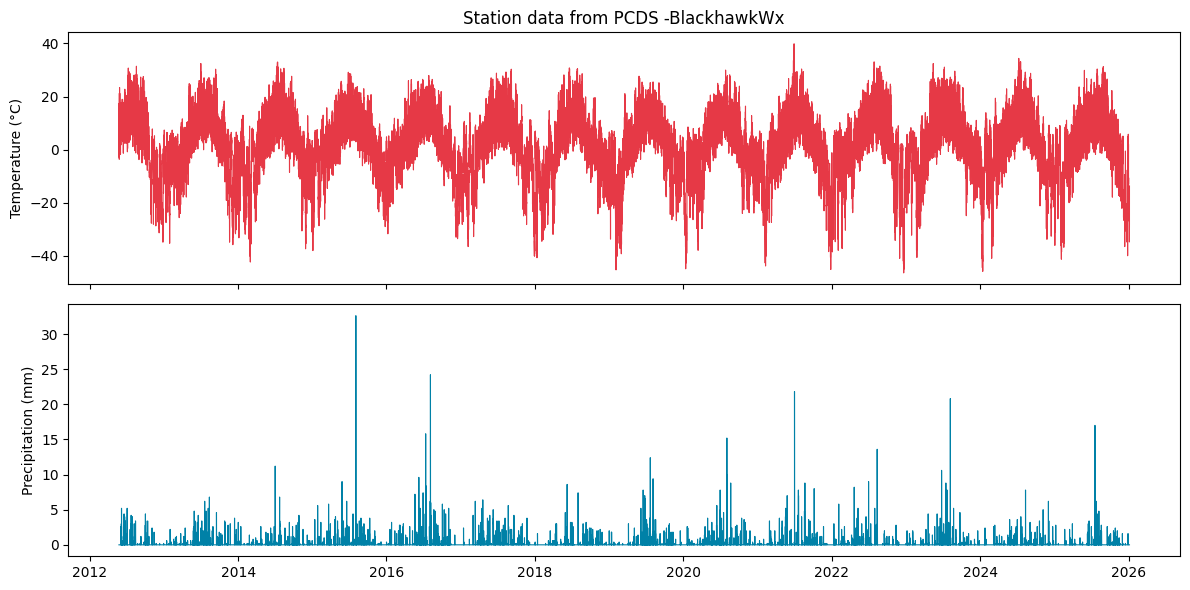

In [70]:
sql_text = sa.text("""
SELECT o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 11
AND h.station_name = 'BlackhawkWx'
AND v.net_var_name IN ('TempC', 'Rainmm')
""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

# convert time
df["obs_time"] = pd.to_datetime(df["obs_time"])

# pivot → columns = variables
df_sql = df.pivot_table(
    index="obs_time",
    columns="net_var_name",
    values="datum"
)

# rename for clarity
df_sql = df_sql.rename(columns={
    "TempC": "temp",
    "Rainmm": "precip"
})

# sort index
df_sql = df_sql.sort_index()
df_sql


plot_weather_data(df_sql, title = 'Station data from PCDS -BlackhawkWx')

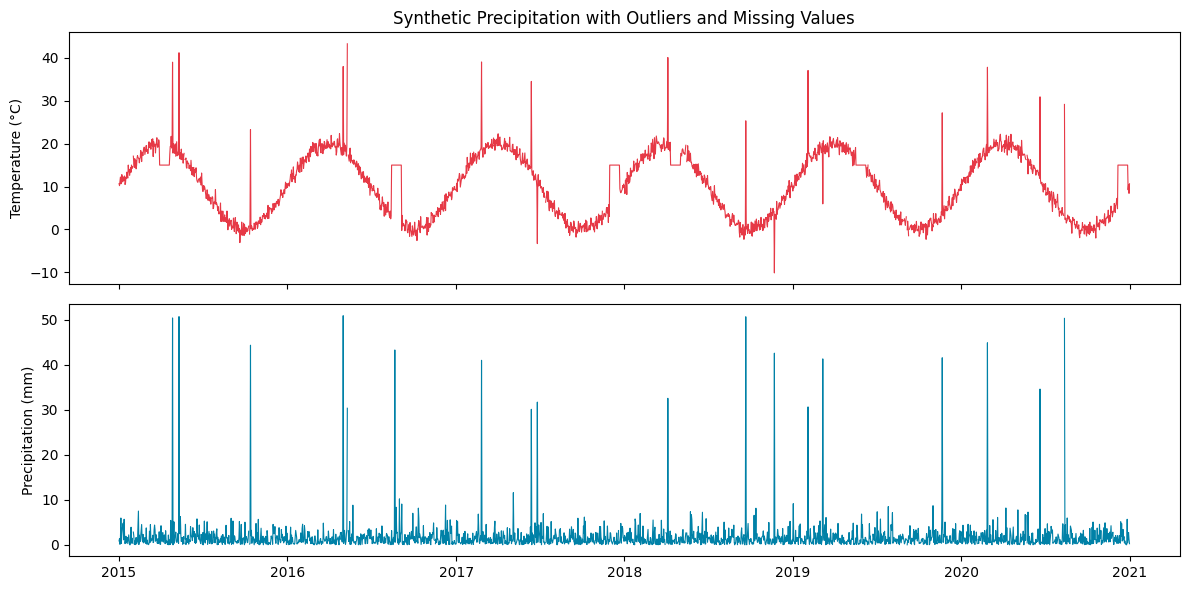

In [71]:
df_test_tas_pr = generate_synthetic_weather_data()

plot_weather_data(df_test_tas_pr, title = "Synthetic Precipitation with Outliers and Missing Values")

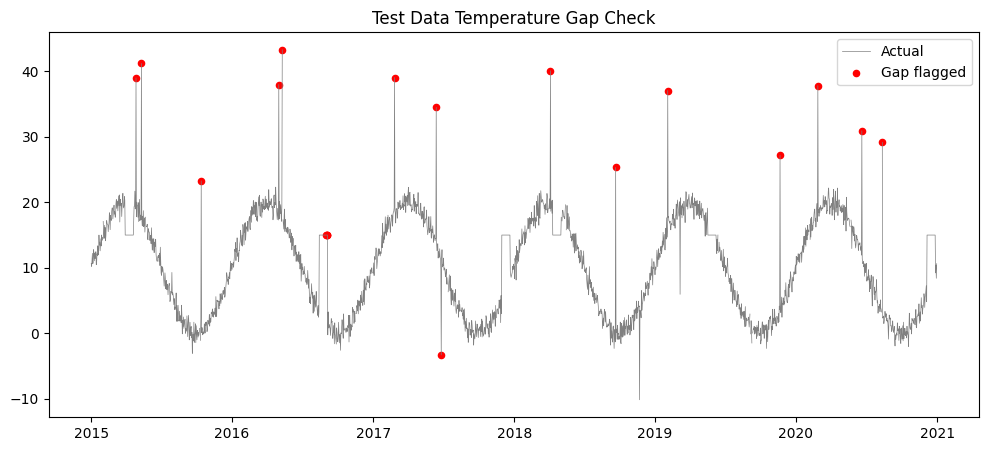

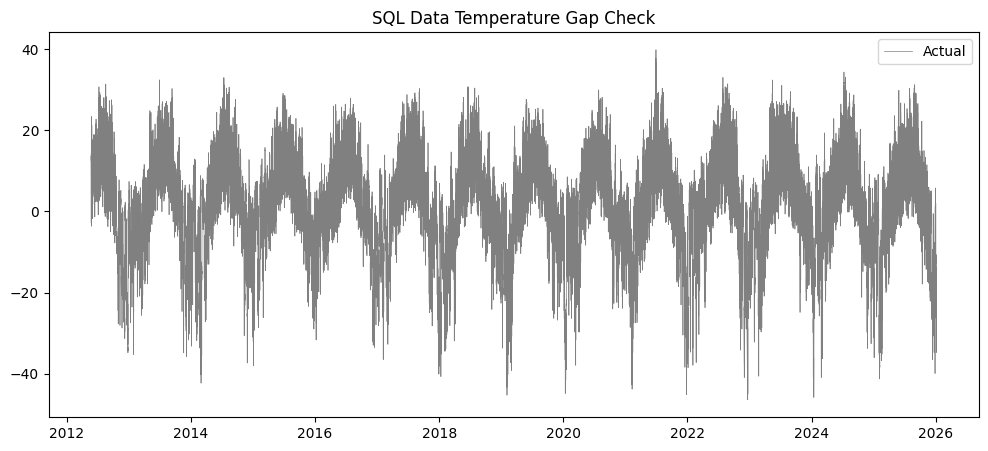

In [61]:
import numpy as np
import pandas as pd


def gap_check_temperature(df, col="temp", gap_threshold=10):
    """
    Gap check for temperature (two-tailed)

    Returns:
        flagged_indices: list of timestamps flagged as outliers
    """

    flagged = []

    # loop over months (1–12)
    for month in range(1, 13):

        # select all values for this calendar month
        sub = df[df.index.month == month][col].dropna()

        if len(sub) < 10:
            continue

        values = sub.values
        times = sub.index

        # --- sort ---
        sort_idx = np.argsort(values)
        sorted_vals = values[sort_idx]
        sorted_times = times[sort_idx]

        # --- median split ---
        median = np.median(sorted_vals)

        lower_mask = sorted_vals <= median
        upper_mask = sorted_vals >= median

        # --- check lower tail ---
        lower_vals = sorted_vals[lower_mask]
        lower_times = sorted_times[lower_mask]

        if len(lower_vals) > 1:
            diffs = np.diff(lower_vals)

            for i in range(len(diffs)):
                if diffs[i] > gap_threshold:
                    flagged.extend(lower_times[:i+1])  # everything below gap
                    break

        # --- check upper tail ---
        upper_vals = sorted_vals[upper_mask]
        upper_times = sorted_times[upper_mask]

        if len(upper_vals) > 1:
            diffs = np.diff(upper_vals)

            for i in range(len(diffs)):
                if diffs[i] > gap_threshold:
                    flagged.extend(upper_times[i+1:])  # everything above gap
                    break

    return sorted(set(flagged))

def process_and_plot_gaps(df, check_fun, title="Gap Check", col="temp", threshold=10):
    # 1. Run the gap check logic
    flagged_indices = check_fun(df, col=col, gap_threshold=threshold)
    
    # 2. Create the plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot the base data
    ax.plot(df.index, df[col], color="gray", lw=0.5, label="Actual")
    
    # Overlay the flagged outliers
    if flagged_indices:
        ax.scatter(
            flagged_indices, 
            df.loc[flagged_indices, col], 
            color="red", 
            s=20, 
            label="Gap flagged"
        )
    
    ax.set_title(title)
    ax.legend()
    plt.show()
    
    return flagged_indices

gap_temp_test = process_and_plot_gaps(df_test, gap_check_temperature, threshold = 10, col = 'temp', title="Test Data Temperature Gap Check")
gap_temp_sql  = process_and_plot_gaps(df_sql, gap_check_temperature,  threshold = 10, col = 'temp', title="SQL Data Temperature Gap Check")

[Timestamp('2015-10-13 00:00:00'), Timestamp('2016-08-21 00:00:00'), Timestamp('2018-09-21 00:00:00'), Timestamp('2018-11-22 00:00:00'), Timestamp('2019-03-07 00:00:00'), Timestamp('2019-11-21 00:00:00'), Timestamp('2020-08-12 00:00:00')]


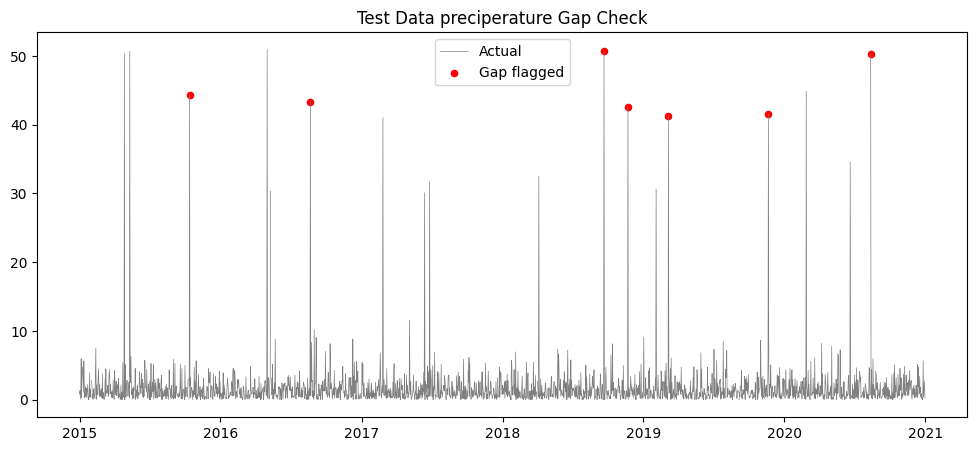

[]


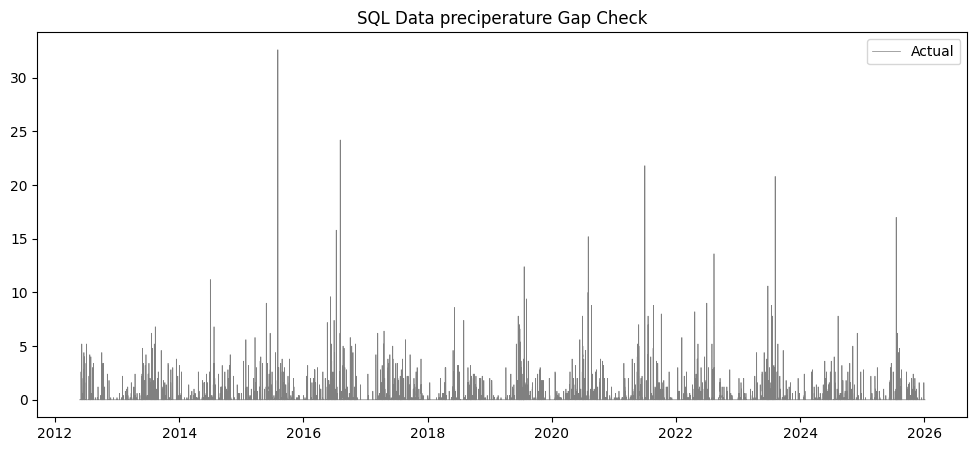

In [63]:
def gap_check_precip(df, col="precip", gap_threshold=300):
    """
    Gap check for precipitation (one-tailed, positive skew)
    """

    flagged = []

    for month in range(1, 13):

        sub = df[df.index.month == month][col].dropna()

        # ignore zeros
        sub = sub[sub > 0]

        if len(sub) < 10:
            continue

        values = sub.values
        times = sub.index

        sort_idx = np.argsort(values)
        sorted_vals = values[sort_idx]
        sorted_times = times[sort_idx]

        diffs = np.diff(sorted_vals)

        for i in range(len(diffs)):
            if diffs[i] > gap_threshold:
                flagged.extend(sorted_times[i+1:])  # high-end tail
                break

    print(sorted(set(flagged)))
    return sorted(set(flagged))

# --- Now your main code becomes just two lines ---
gap_precip_test = process_and_plot_gaps(df_test, gap_check_precip, threshold = 30, col = 'precip', title="Test Data preciperature Gap Check")
gap_precip_sql  = process_and_plot_gaps(df_sql, gap_check_precip, threshold = 30, col = 'precip',  title="SQL Data preciperature Gap Check")
